# **KHAI BÁO THƯ VIỆN**

In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import numpy as np

In [40]:
# Load dữ liệu
df = pd.read_csv('data_final.csv')

# **CÂU HỎI**

## Phân tích các yếu tố (nhân khẩu học và các loại áp lực: học tập/công việc, tài chính) ảnh hưởng đến nguy cơ trầm cảm giữa sinh viên và người đi làm.


- Từ câu hỏi tổng quan tiến hành phân tách thành các câu hỏi nhỏ:

  * Sự khác biệt về tỷ lệ trầm cảm giữa Student và Working Professional? Đặc điểm giới tính, độ tuổi, nghề nghiệp của người bị trầm cảm trong hai nhóm này như thế nào?

  * Mối quan hệ giữa áp lực (học tập/công việc) và mức độ hài lòng (học tập/công việc) ở người đã mắc trầm cảm ra sao? Khi áp lực tăng từ 1 đến 5, xác suất trầm cảm thay đổi như thế nào và nhóm nào tăng nhanh hơn?

  * Áp lực tài chính (Financial Stress) ảnh hưởng như thế nào đến tỷ lệ trầm cảm ở hai nhóm Student và Working Professional?

### **PHÂN TÍCH CHI TIẾT**:

#### a. Sự khác biệt về tỷ lệ trầm cảm giữa Student và Working Professional? Đặc điểm giới tính, độ tuổi, nghề nghiệp của người bị trầm cảm trong hai nhóm này như thế nào?
  

In [41]:
# Tỷ lệ trầm cảm (%)
depression_rate = df.groupby('Working Professional or Student')['Depression'].mean() * 100

group_count = df['Working Professional or Student'].value_counts()

print("Tỷ lệ trầm cảm (%):")
print(depression_rate)

print("\nSố lượng từng nhóm:")
print(group_count)

Tỷ lệ trầm cảm (%):
Working Professional or Student
Student                 58.554001
Working Professional     8.175593
Name: Depression, dtype: float64

Số lượng từng nhóm:
Working Professional or Student
Working Professional    112738
Student                  27870
Name: count, dtype: int64


#### Nhận xét:
- Kết quả phân tích cho thấy sự khác biệt rất rõ rệt về tình trạng trầm cảm giữa hai nhóm.
- Nhóm sinh viên có tỷ lệ trầm cảm lên tới 58.55% trên tổng số 27,870 người, trong khi nhóm người đi làm chỉ có 8.18% trên 112,738 người.
- Mặc dù quy mô nhóm sinh viên nhỏ hơn đáng kể (chỉ khoảng 1/4 so với người đi làm), nhưng số lượng sinh viên có dấu hiệu trầm cảm ước tính vẫn cao hơn (khoảng 16,300 người so với khoảng 9,200 người đi làm).

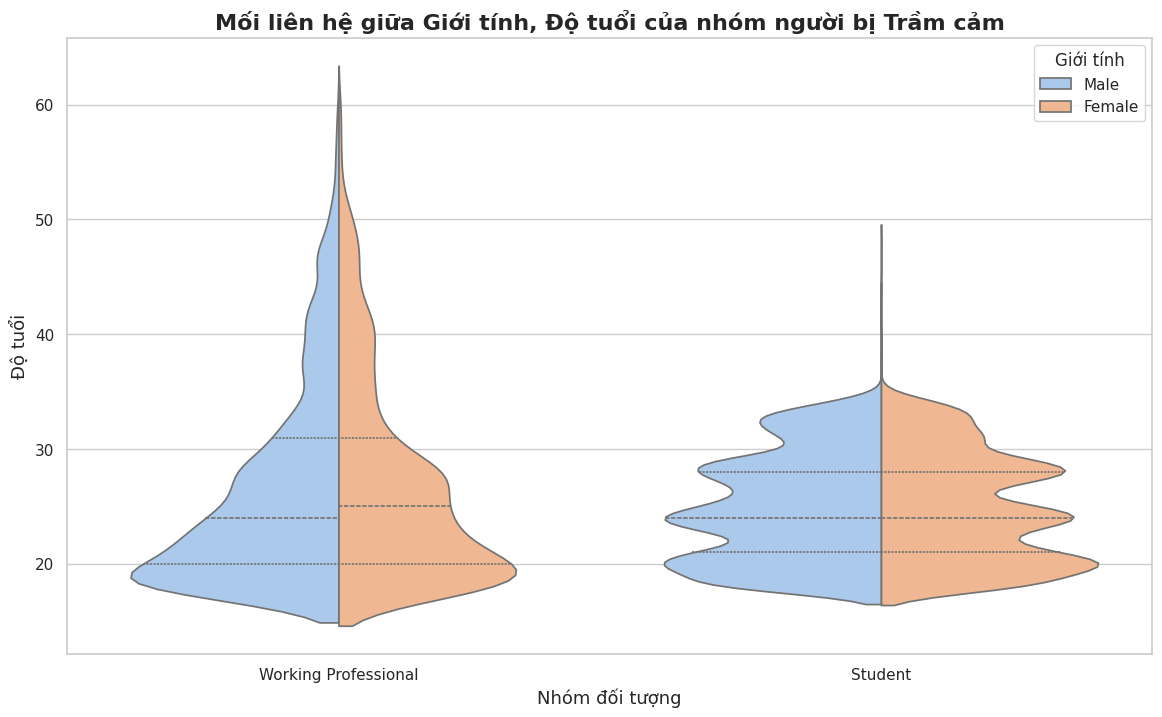

Thống kê độ tuổi trầm cảm theo Giới tính và Nhóm:
                                             mean  median  count
Working Professional or Student Gender                          
Student                         Female  24.867184    24.0   7213
                                Male    24.901384    24.0   9106
Working Professional            Female  27.101510    25.0   4039
                                Male    26.435496    24.0   5178


In [42]:
# Lọc chỉ lấy những người bị trầm cảm
depressed_df = df[df['Depression'] == 1]
# Vẽ biểu đồ
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")
# Sử dụng Violin Plot
sns.violinplot(
    data=depressed_df,
    x='Working Professional or Student',
    y='Age',
    hue='Gender',
    split=True,
    inner="quart",  # Hiển thị các đường tứ phân vị (trung vị, 25%, 75%)
    palette="pastel"
)

plt.title('Mối liên hệ giữa Giới tính, Độ tuổi của nhóm người bị Trầm cảm', fontsize=16, fontweight='bold')
plt.xlabel('Nhóm đối tượng', fontsize=13)
plt.ylabel('Độ tuổi', fontsize=13)
plt.legend(title='Giới tính', loc='upper right')

plt.show()

# Bảng thống kê
summary = depressed_df.groupby(['Working Professional or Student', 'Gender'])['Age'].agg(['mean', 'median', 'count'])
print("Thống kê độ tuổi trầm cảm theo Giới tính và Nhóm:")
print(summary)

#### Nhận xét:
- Thống kê cho thấy độ tuổi trung bình của người bị trầm cảm ở Working Professional (khoảng 26–27 tuổi) cao hơn so với Student (khoảng 24–25 tuổi).
- Trong cả hai nhóm, sự chênh lệch giữa nam và nữ là không đáng kể, với giá trị trung bình và trung vị gần như tương đương nhau.

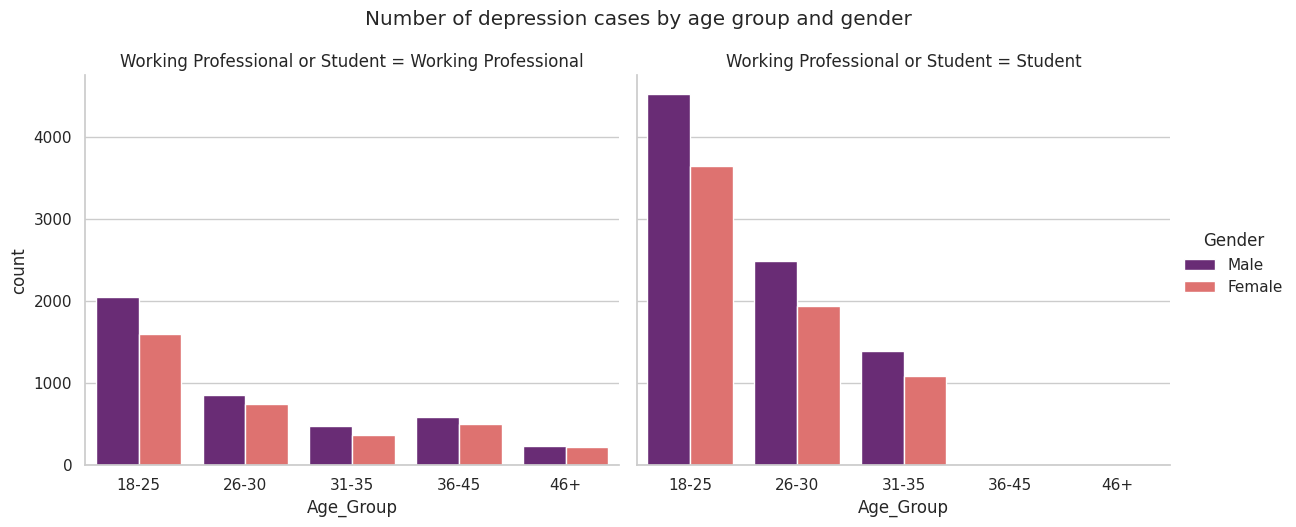

In [43]:
# Vẽ biểu đồ đếm số lượng theo nhóm tuổi (gộp 5 năm 1 lần)
df['Age_Group'] = pd.cut(df['Age'], bins=[18, 25, 30, 35, 45, 60], labels=['18-25', '26-30', '31-35', '36-45', '46+'])

g = sns.catplot(
    data=df[df['Depression']==1],
    kind="count",
    x="Age_Group", hue="Gender", col="Working Professional or Student",
    palette="magma", height=5, aspect=1.2
)
g.fig.suptitle('Number of depression cases by age group and gender', y=1.05)
plt.show()

#### Nhận xét:
- Biểu đồ cho thấy số ca trầm cảm tập trung chủ yếu ở nhóm tuổi 18–25 và giảm dần theo độ tuổi ở cả hai nhóm đối tượng.
- Nhóm Student có số ca cao vượt trội, đặc biệt ở độ tuổi trẻ, trong khi Working Professional phân bố trải rộng hơn nhưng tổng số thấp hơn.  
- Ngoài ra, số lượng nam bị trầm cảm nhiều hơn nữ ở cả hai nhóm, đặc biệt là ở nhóm sinh viên.

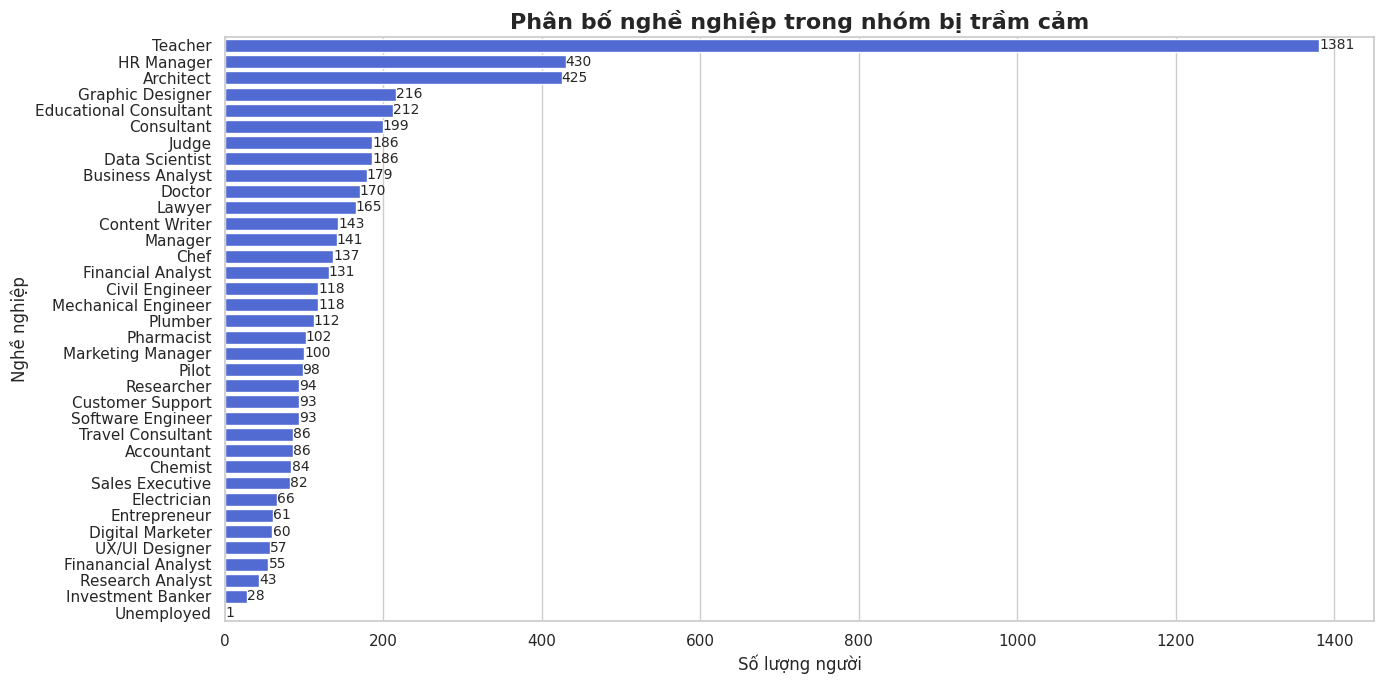

In [44]:
# Lọc chỉ người đi làm
working_df = df[df['Working Professional or Student'] == 'Working Professional'].copy()
# Bỏ "Other"
working_df = working_df[working_df['Profession'] != 'Other']
#  Chỉ lấy người bị trầm cảm
depressed_work = working_df[working_df['Depression'] == 1].copy()

# Vẽ biểu đồ
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

ax = sns.countplot(
    data=depressed_work,
    y='Profession',
    color="#3c5ee7",
    order=depressed_work['Profession'].value_counts().index
)

plt.title('Phân bố nghề nghiệp trong nhóm bị trầm cảm', fontsize=16, fontweight='bold')
plt.xlabel('Số lượng người', fontsize=12)
plt.ylabel('Nghề nghiệp', fontsize=12)

# Ghi số lên cột
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.text(width + 0.1, p.get_y() + p.get_height()/2,
                f'{int(width)}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

#### Nhận xét:

- Biểu đồ cho thấy Teacher có số ca trầm cảm cao vượt trội, đây là một insight đáng chú ý vì nghề này thường chịu áp lực từ nhiều phía như giảng dạy, quản lý học sinh và kỳ vọng xã hội.
- Các nhóm nghề như HR, Architect, Designer hay Consultant cũng có số lượng cao (hầu như đều >=200 người)
- Ngoài ra, sự phân bố rộng ở nhiều ngành cho thấy trầm cảm không chỉ tập trung ở một lĩnh vực cụ thể mà mang tính phổ biến.

## Kết luận:

- Tỷ lệ trầm cảm ở nhóm Student cao vượt trội so với Working Professional, cho thấy sinh viên là nhóm có nguy cơ gặp vấn đề sức khỏe tâm lý lớn hơn nhiều.
- Trầm cảm cũng tập trung chủ yếu ở độ tuổi 18–25 và giảm dần theo thời gian, trong đó sinh viên chiếm phần lớn số ca ở nhóm tuổi trẻ. Điều này gợi ý rằng áp lực học tập, sự thiếu ổn định và định hướng tương lai chưa rõ ràng khiến họ dễ bị tổn thương hơn, trong khi người đi làm có thể thích nghi tốt hơn nhờ kinh nghiệm sống.

- Ở nhóm Working Professional, nguy cơ trầm cảm không phân bố đồng đều mà phụ thuộc vào đặc thù nghề nghiệp, với các ngành như giáo viên, HR, tư vấn hay thiết kế có số ca cao hơn.
- Điều này cho thấy các công việc đòi hỏi tương tác nhiều, sáng tạo hoặc chịu áp lực liên tục dễ làm gia tăng căng thẳng tâm lý. Nhìn chung, trầm cảm phổ biến hơn ở sinh viên, nhưng ở người đi làm, mức độ ảnh hưởng lại gắn chặt với môi trường và tính chất công việc.

####b. Mối quan hệ giữa áp lực (học tập/công việc) và mức độ hài lòng (học tập/công việc) ở người đã mắc trầm cảm ra sao? Khi áp lực tăng từ 1 đến 5, xác suất trầm cảm thay đổi như thế nào và nhóm nào tăng nhanh hơn?

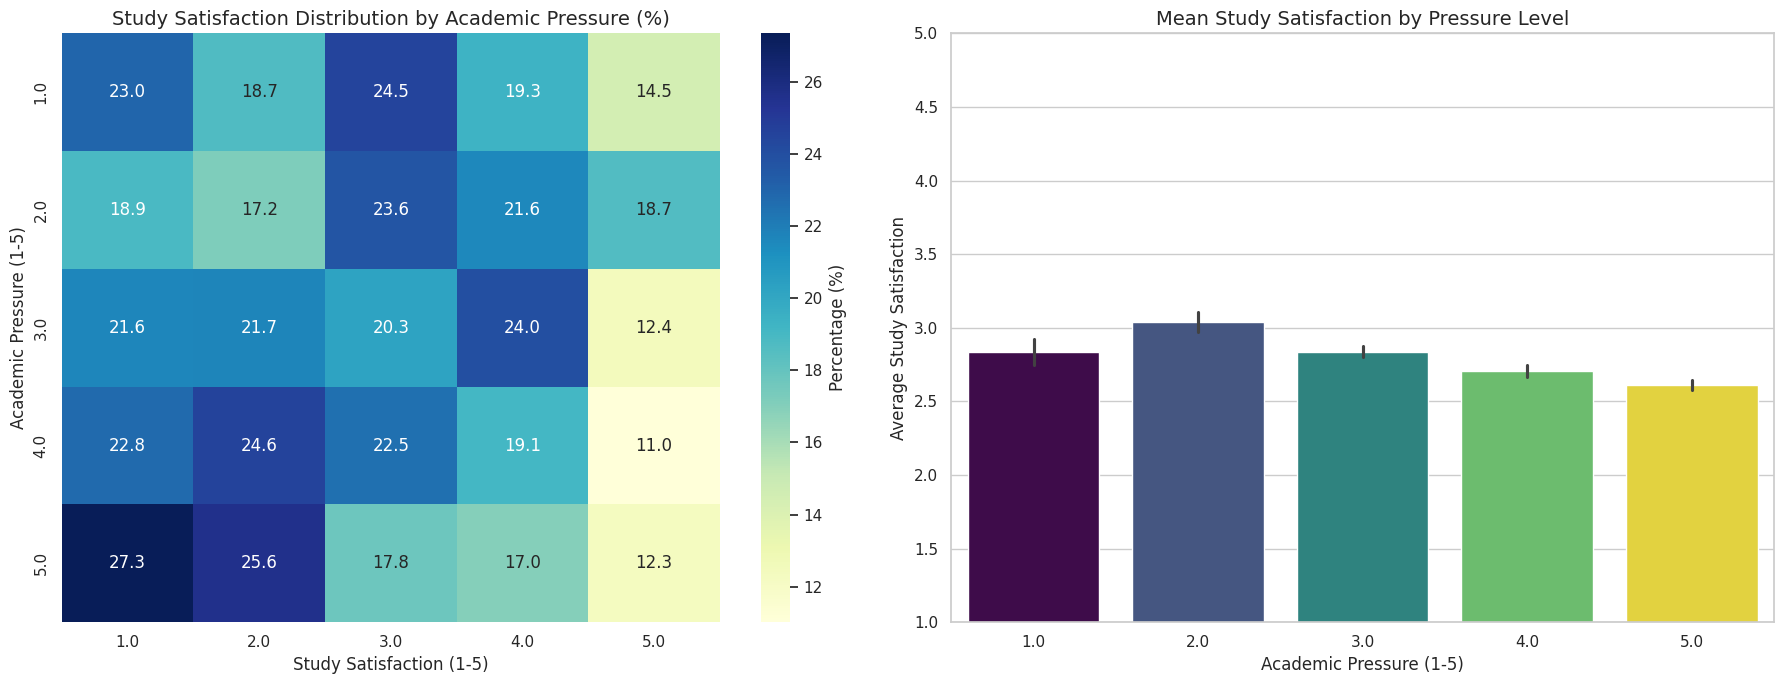

Hệ số tương quan Spearman (Sinh viên bị trầm cảm): -0.0917


In [45]:
df_depressed = df[df['Depression'] == 1].copy()
students = df_depressed[df_depressed['Working Professional or Student'] == 'Student']
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

#BIỂU ĐỒ 1: Heatmap Tỷ lệ %
ct_student = pd.crosstab(students['Academic Pressure'], students['Study Satisfaction'], normalize='index') * 100
sns.heatmap(ct_student, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Percentage (%)'}, ax=axes[0])
axes[0].set_title('Study Satisfaction Distribution by Academic Pressure (%)', fontsize=14)
axes[0].set_xlabel('Study Satisfaction (1-5)', fontsize=12)
axes[0].set_ylabel('Academic Pressure (1-5)', fontsize=12)

# BIỂU ĐỒ 2: Mức hài lòng trung bình (Bar chart)
sns.barplot(
    data=students,
    x='Academic Pressure',
    y='Study Satisfaction',
    estimator=np.mean,
    palette='viridis',
    hue='Academic Pressure',
    legend=False,
    ax=axes[1]
)
axes[1].set_title('Mean Study Satisfaction by Pressure Level', fontsize=14)
axes[1].set_xlabel('Academic Pressure (1-5)', fontsize=12)
axes[1].set_ylabel('Average Study Satisfaction', fontsize=12)
axes[1].set_ylim(1, 5)

# Hiển thị
plt.tight_layout()
plt.show()

# Tính và in tương quan Spearman
corr_student = students['Academic Pressure'].corr(students['Study Satisfaction'], method='spearman')
print(f"Hệ số tương quan Spearman (Sinh viên bị trầm cảm): {corr_student:.4f}")

####Nhận xét:
+ Dựa trên hệ số tương quan Spearman ($-0.0917$) và các biểu đồ trực quan, có thể thấy mối quan hệ giữa áp lực học tập và mức độ hài lòng ở sinh viên mắc trầm cảm là nghịch chiều nhưng rất yếu.
+ Điều này cho thấy khi áp lực thay đổi, mức độ hài lòng gần như không biến động đáng kể.
+ Heatmap cho thấy ở mọi mức áp lực, tỷ lệ sinh viên có mức hài lòng thấp vẫn chiếm đa số.
+ Điều này cho thấy áp lực học tập không còn là yếu tố quyết định chính đối với mức độ hài lòng ở nhóm đã mắc trầm cảm.

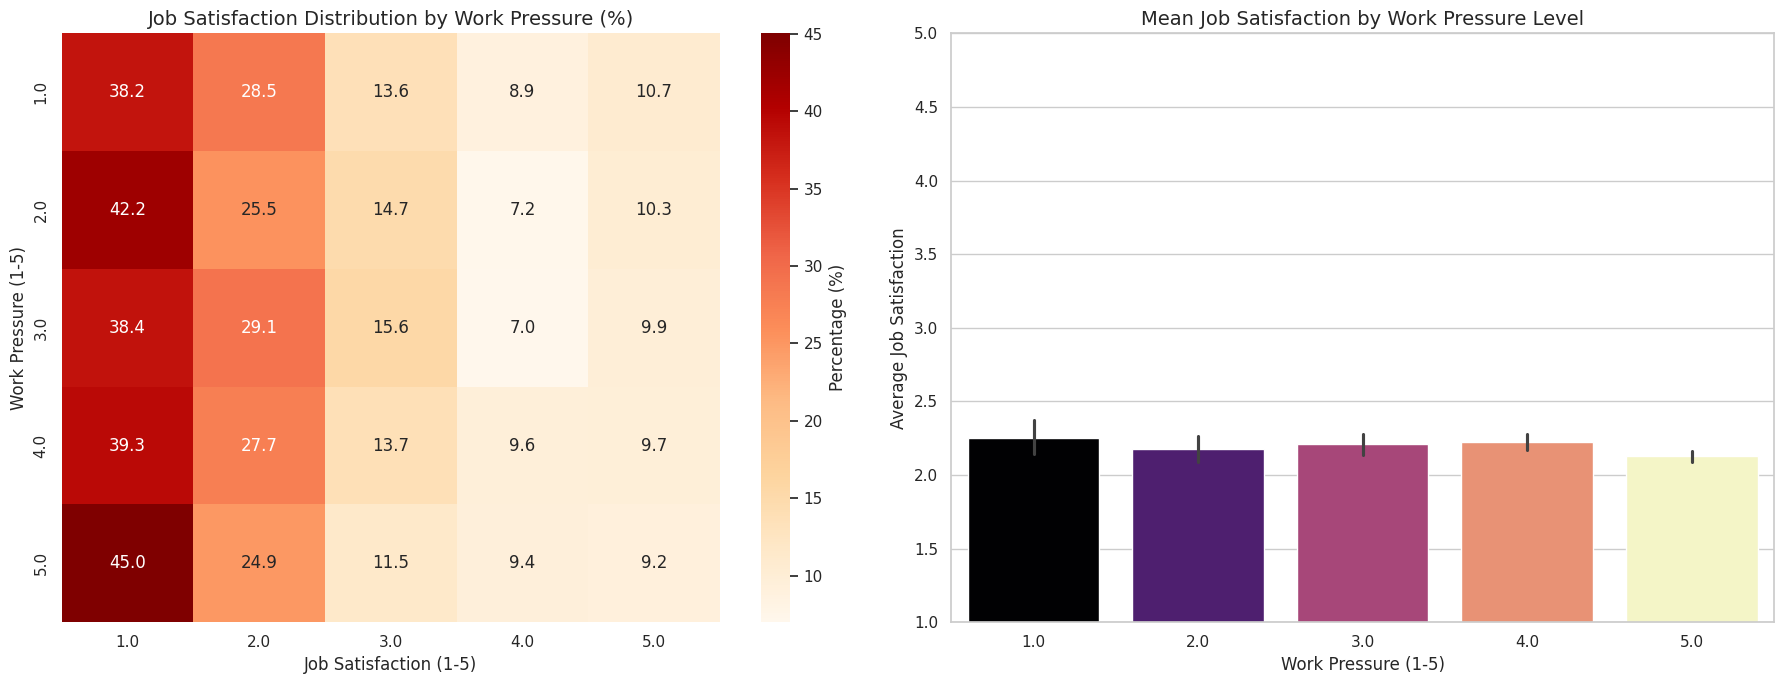

Hệ số tương quan Spearman (Người đi làm bị trầm cảm): -0.0408


In [49]:
df_depressed = df[df['Depression'] == 1].copy()
professionals = df_depressed[df_depressed['Working Professional or Student'] == 'Working Professional']

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# BIỂU ĐỒ 1: Heatmap Tỷ lệ %-
ct_pro = pd.crosstab(professionals['Work Pressure'], professionals['Job Satisfaction'], normalize='index') * 100
sns.heatmap(ct_pro, annot=True, fmt=".1f", cmap="OrRd", cbar_kws={'label': 'Percentage (%)'}, ax=axes[0])
axes[0].set_title('Job Satisfaction Distribution by Work Pressure (%)', fontsize=14)
axes[0].set_xlabel('Job Satisfaction (1-5)', fontsize=12)
axes[0].set_ylabel('Work Pressure (1-5)', fontsize=12)

# BIỂU ĐỒ 2: Mức hài lòng trung bình (Bar chart)
sns.barplot(
    data=professionals,
    x='Work Pressure',
    y='Job Satisfaction',
    estimator=np.mean,
    palette='magma',
    hue='Work Pressure',
    legend=False,
    ax=axes[1]
)
axes[1].set_title('Mean Job Satisfaction by Work Pressure Level', fontsize=14)
axes[1].set_xlabel('Work Pressure (1-5)', fontsize=12)
axes[1].set_ylabel('Average Job Satisfaction', fontsize=12)
axes[1].set_ylim(1, 5)

# Hiển thị
plt.tight_layout()
plt.show()

# Tính và in tương quan Spearman
corr_pro = professionals['Work Pressure'].corr(professionals['Job Satisfaction'], method='spearman')
print(f"Hệ số tương quan Spearman (Người đi làm bị trầm cảm): {corr_pro:.4f}")

####Nhận xét:  
+ Nhìn vào biểu đồ Heatmap, ta thấy dù ở mức áp lực thấp hay cao (từ 1 đến 5), tỷ lệ người cảm thấy hài lòng ở mức thấp (mức 1.0) vẫn chiếm đa số (trên 38-45%).
+ Hệ số tương quan $-0.0408$ là một con số cực kỳ thấp (gần như không có mối liên hệ tuyến tính hay thứ bậc nào). Điều này gây bất ngờ lớn vì trong tư duy thông thường, người ta tin rằng áp lực công việc ít đi thì sẽ người đó sẽ hài lòng hơn. Nhưng điều này chưa chắc đúng với người bị trầm cảm.
+ Mức độ hài lòng công việc nhìn chung luôn thấp và không thay đổi rõ rệt theo mức áp lực. Điều này cho thấy việc giảm áp lực công việc đơn thuần chưa đủ để cải thiện cảm xúc ở người đã mắc trầm cảm, vì các yếu tố khác có thể chi phối mạnh hơn.

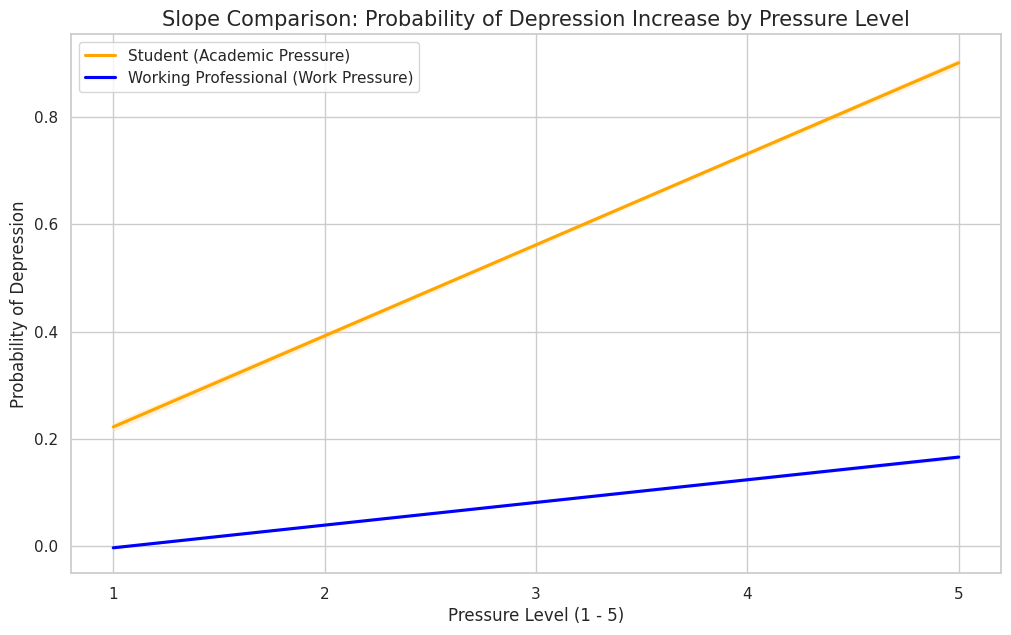

Độ tương quan (Correlation) với trầm cảm:
Working Professional or Student
Student                 0.475011
Working Professional    0.216695
dtype: float64


/tmp/ipykernel_5417/1124518462.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correlation = df.groupby('Working Professional or Student').apply(


In [50]:

df['Pressure_Level'] = df['Academic Pressure'].fillna(0) + df['Work Pressure'].fillna(0)


plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Vẽ đường hồi quy cho từng nhóm
sns.regplot(
    data=df[df['Working Professional or Student'] == 'Student'],
    x='Pressure_Level', y='Depression',
    scatter=False, label='Student (Academic Pressure)', color='orange'
)

sns.regplot(
    data=df[df['Working Professional or Student'] == 'Working Professional'],
    x='Pressure_Level', y='Depression',
    scatter=False, label='Working Professional (Work Pressure)', color='blue'
)

plt.title('Slope Comparison: Probability of Depression Increase by Pressure Level', fontsize=15)
plt.xlabel('Pressure Level (1 - 5)', fontsize=12)
plt.ylabel('Probability of Depression', fontsize=12)
plt.xticks([1, 2, 3, 4, 5])
plt.legend()
plt.show()

# Độ tương quan
correlation = df.groupby('Working Professional or Student').apply(
    lambda x: x['Pressure_Level'].corr(x['Depression'])
)
print("Độ tương quan (Correlation) với trầm cảm:")
print(correlation)

####Nhận xét:
- Biểu đồ cho thấy khi mức độ áp lực tăng, xác suất bị trầm cảm đều tăng ở cả sinh viên và người đi làm.
- Tuy nhiên, sinh viên nhạy cảm hơn rõ rệt, với mức tăng nhanh và mạnh hơn nhiều so với người đi làm.
- Khoảng cách giữa hai nhóm cũng ngày càng lớn ở mức áp lực cao.

##KẾT LUẬN:
+ Kết quả phân tích cho thấy có mối liên hệ rõ ràng giữa áp lực (học tập/công việc) và xác suất mắc trầm cảm ở cả hai nhóm sinh viên và người đi làm. Khi mức độ áp lực tăng, nguy cơ trầm cảm cũng tăng theo, trong đó sinh viên thể hiện mức độ nhạy cảm cao hơn rõ rệt so với người đi làm.
+ Trong nhóm người mắc trầm cảm, mối quan hệ giữa áp lực và mức độ hài lòng là rất yếu ở cả hai nhóm (Student: -0.0917, Worker: -0.0408). Điều này cho thấy trạng thái trầm cảm làm suy giảm đáng kể cảm giác hài lòng vào các yếu tố áp lực bên ngoài.
+ Hiện tượng này rõ hơn ở người đi làm, nơi mà sự thay đổi áp lực hầu như không kéo theo thay đổi tương ứng về mức độ hài lòng. Điều này chứng tỏ môi trường công sở với các gánh nặng trách nhiệm có thể khiến người bị trầm cảm rơi vào trạng thái bế tắc sâu sắc hơn, nơi mà việc giảm áp lực đơn thuần hầu như không mang lại sự cải thiện nào cho cảm xúc.
+ Tổng hợp lại, áp lực là yếu tố có ảnh hưởng rõ ràng đến nguy cơ trầm cảm, nhưng khi trầm cảm đã xuất hiện, mối liên hệ giữa áp lực và cảm xúc hài lòng trở nên rất yếu, cho thấy các yếu tố tâm lý nội tại có thể đóng vai trò chi phối đến cảm xúc lớn hơn so với áp lực bên ngoài.

####c. Áp lực tài chính (Financial Stress) ảnh hưởng như thế nào đến tỷ lệ trầm cảm ở hai nhóm Student và Working Professional?

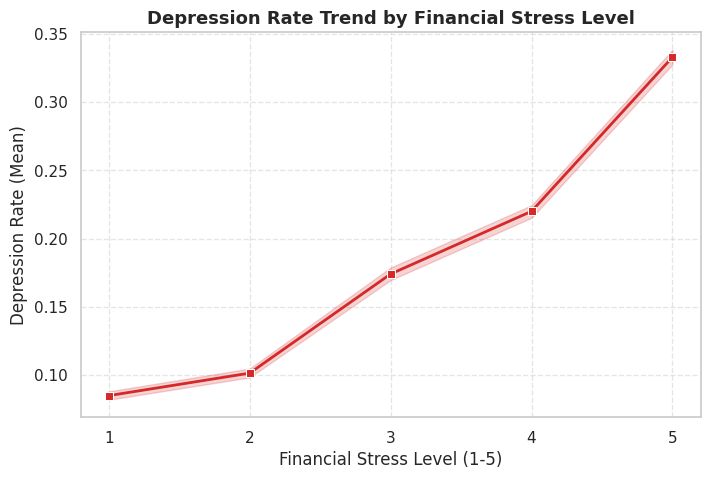

In [51]:
plt.figure(figsize=(8, 5))

sns.lineplot(
    data=df,
    x='Financial Stress',
    y='Depression',
    marker='s',
    color='#D62828',
    linewidth=2
)

plt.title('Depression Rate Trend by Financial Stress Level', fontsize=13, fontweight='bold')
plt.xlabel('Financial Stress Level (1-5)')
plt.ylabel('Depression Rate (Mean)')
plt.xticks([1, 2, 3, 4, 5])

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

####Nhận xét:
Biểu đồ đường cho thấy một xu hướng đi lên gần như tuyến tính. Khi mức độ áp lực tài chính càng cao, xác suất một cá nhân mắc trầm cảm càng tăng vọt. Điều này khẳng định Financial Stress là một trong những biến số rủi ro (risk factor) hàng đầu gây ảnh hưởng trực tiếp đến sức khỏe tâm thần trong bộ dữ liệu này.

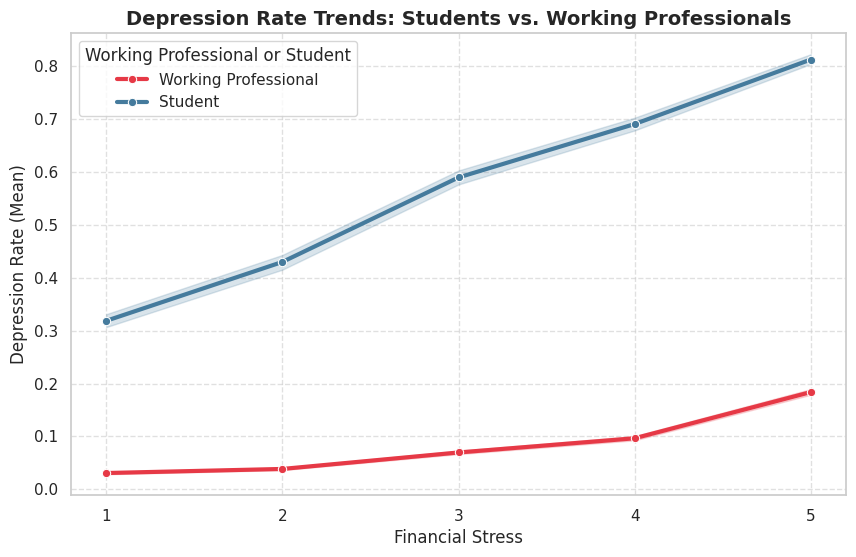

In [52]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=df,
    x='Financial Stress',
    y='Depression',
    hue='Working Professional or Student',
    marker='o',
    linewidth=3,
    palette=['#E63946', '#457B9D']
)

plt.title('Depression Rate Trends: Students vs. Working Professionals', fontsize=14, fontweight='bold')
plt.xlabel('Financial Stress')
plt.ylabel('Depression Rate (Mean)')
plt.xticks([1, 2, 3, 4, 5])

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

####Nhận xét:
+ Áp lực tài chính tỉ lệ thuận và tương quan mạnh với trầm cảm ở cả hai nhóm, áp lực tài chính càng cao, tỷ lệ trầm cảm càng tăng rõ rệt.
+ Sinh viên dễ tổn thương hơn, thể hiện qua việc tỷ lệ trầm cảm cao ngay cả khi áp lực tài chính thấp, do thiếu ổn định và kỹ năng đối phó với áp lực.
+ Người đi làm có tỷ lệ trầm cảm ban đầu thấp hơn nhưng phản ứng mạnh khi áp lực tài chính tăng, do phải duy trì cuộc sống.


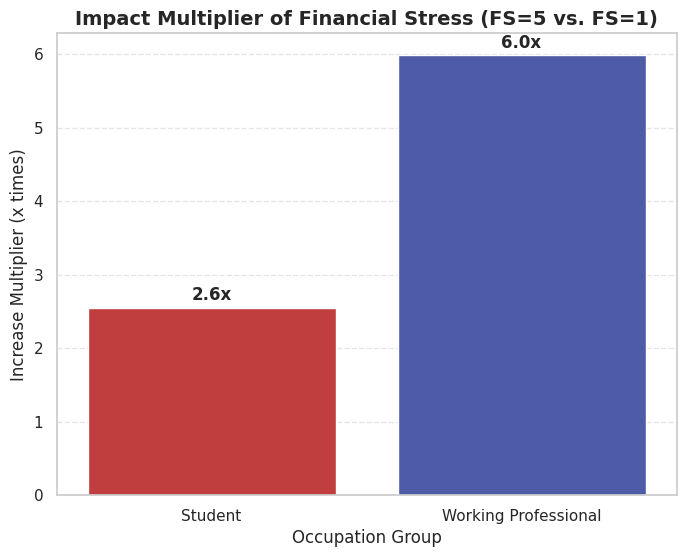

In [53]:
# Lấy tỷ lệ trầm cảm ở mức FS=1 (nền) cho mỗi nhóm
df_fs1 = df[df['Financial Stress'] == 1]
baseline_rates = df_fs1.groupby('Working Professional or Student')['Depression'].mean()

# Lấy tỷ lệ trầm cảm ở mức FS=5 (tối đa) cho mỗi nhóm
df_fs5 = df[df['Financial Stress'] == 5]
max_stress_rates = df_fs5.groupby('Working Professional or Student')['Depression'].mean()

# Tính hệ số nhân và đưa vào bảng impact_df
impact_multipliers = max_stress_rates / baseline_rates
impact_df = impact_multipliers.reset_index(name='Impact Multiplier')
# VẼ BIỂU ĐỒ
plt.figure(figsize=(8, 6))
sns.barplot(
    data=impact_df,
    x='Working Professional or Student',
    y='Impact Multiplier',
    hue='Working Professional or Student',
    palette=['#D62828', '#3F51B5'],
    legend=False
)

plt.title('Impact Multiplier of Financial Stress (FS=5 vs. FS=1)', fontsize=14, fontweight='bold')
plt.ylabel('Increase Multiplier (x times)', fontsize=12)
plt.xlabel('Occupation Group', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for i, v in enumerate(impact_df['Impact Multiplier']):
    plt.text(i, v + 0.1, f"{v:.1f}x", ha='center', fontsize=12, fontweight='bold')

plt.show()

####Nhận xét:
+ Khi chuẩn hóa cùng mức xuất phát (FS=1), có thể thấy người đi làm nhạy cảm hơn rõ rệt với áp lực tài chính: nguy cơ trầm cảm tăng khoảng 6 lần khi FS=5 so với khi FS=1, dù mức ban đầu thấp hơn so với sinh viên. Điều này cho thấy áp lực tài chính có tác động rất mạnh đến trạng thái tâm lý của nhóm này.
+ Ở sinh viên, nguy cơ trầm cảm tăng khoảng 2.6 lần khi áp lực tăng. Mức tăng thấp hơn không phải vì ít bị ảnh hưởng, mà do tỷ lệ trầm cảm ban đầu đã cao, khiến tác động gia tăng trở nên kém đột biến hơn.

## KẾT LUẬN
+ Áp lực tài chính (Financial Stress) là yếu tố có ảnh hưởng mạnh đến trầm cảm ở cả sinh viên và người đi làm: khi áp lực tài chính tăng, tỷ lệ trầm cảm đều tăng rõ rệt.
+ Sinh viên có mức trầm cảm cao ngay từ khi áp lực tài chính thấp. Ngược lại, người đi làm có tỷ lệ ban đầu thấp hơn nhưng nhạy cảm hơn với sự gia tăng áp lực tài chính, thể hiện qua mức tăng nguy cơ trầm cảm mạnh hơn (≈6 lần so với 2.6 lần ở sinh viên).
+ Tổng hợp lại, áp lực tài chính không chỉ làm gia tăng nguy cơ trầm cảm mà còn tác động khác nhau lên từng nhóm: sinh viên có tỷ lệ trầm cảm cao ngay cả khi áp lực tài chính thấp, trong khi người đi làm phản ứng mạnh hơn khi áp lực tài chính tăng.